# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Setup — same slice, label, and features as Weeks 5–6

- Reuses the ML-08/ML-09 feature vector (60-day window ending 2025-08-31, one row per content item,
- ≥ 70 impressions in the pre-window).
- Loads the cached parquet when it exists; otherwise rebuilds
it with the identical query and caches it, so every notebook reads the same rows and the numbers match.

In [1]:
import importlib
if any(importlib.util.find_spec(m) is None for m in ("duckdb", "huggingface_hub", "sklearn", "pandas", "numpy", "matplotlib")):
    get_ipython().run_line_magic("pip", "-q install duckdb huggingface_hub scikit-learn pandas numpy matplotlib")

import os
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('hf_key')
except Exception:
    HF_TOKEN = os.getenv('hf_key')
if not HF_TOKEN:
    raise RuntimeError('hf_key not found: set the Colab secret or the hf_key env var')

In [2]:

import duckdb
import numpy as np
import pandas as pd
from pathlib import Path

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':       f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':       f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample': f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
}

repo = Path.cwd()
while not (repo / "work").exists() and repo != repo.parent:
    repo = repo.parent

cache_f = repo / "work" / "outputs" / "w05_feature_vector.parquet"
if cache_f.exists():
    df = pd.read_parquet(cache_f)
    print("loaded cached feature vector:", cache_f)
else:
    df = con.sql(f"""
        WITH bounds AS (SELECT DATE '2025-08-31' AS end_d),
        windowed AS (
            SELECT
                q.client_hash_id,
                q.content_hash_id,
                ANY_VALUE(d.main_intent)    AS main_intent,
                ANY_VALUE(d.content_type)   AS content_type,
                ANY_VALUE(d.search_volume)  AS search_volume,
                SUM(CASE WHEN q.report_date > b.end_d - INTERVAL 60 DAY AND q.report_date <= b.end_d - INTERVAL 30 DAY
                         THEN q.gsc_impressions ELSE 0 END) AS impressions_prev30d,
                SUM(CASE WHEN q.report_date > b.end_d - INTERVAL 30 DAY THEN q.gsc_impressions ELSE 0 END) AS impressions_last30d,
                SUM(CASE WHEN q.report_date > b.end_d - INTERVAL 30 DAY THEN q.gsc_clicks ELSE 0 END) AS clicks_30d,
                AVG(CASE WHEN q.report_date > b.end_d - INTERVAL 30 DAY THEN q.gsc_avg_position END) AS avg_position_30d,
                100.0 * COALESCE(CAST(SUM(CASE WHEN q.report_date > b.end_d - INTERVAL 30 DAY
                                        THEN q.gsc_clicks ELSE 0 END) AS DOUBLE) /
                        NULLIF(SUM(CASE WHEN q.report_date > b.end_d - INTERVAL 30 DAY
                                        THEN q.gsc_impressions ELSE 0 END), 0), 0) AS ctr_label
            FROM {TABLES['fact_daily']} q
            CROSS JOIN bounds b
            JOIN {TABLES['dim_content']} d ON q.content_hash_id = d.content_hash_id
            WHERE q.report_date > b.end_d - INTERVAL 60 DAY
            GROUP BY q.client_hash_id, q.content_hash_id
            HAVING SUM(CASE WHEN q.report_date > b.end_d - INTERVAL 60 DAY
                            AND q.report_date <= b.end_d - INTERVAL 30 DAY
                           THEN q.gsc_impressions ELSE 0 END) >= 70
        )
        SELECT * FROM windowed
    """).df()
    cache_f.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(cache_f, index=False)
    print("wrote cache:", cache_f)

midline = df["ctr_label"].median()
df["at_risk"] = (df["ctr_label"] < midline).astype(int)
print(f"{len(df):,} content items with enough history")
print("base rate (share at-risk in slice):", f"{df['at_risk'].mean():.3f}")

loaded cached feature vector: /work/outputs/w05_feature_vector.parquet
15,310 content items with enough history
base rate (share at-risk in slice): 0.500


In [3]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression

CV, SEED = 5, 42

# honest feature matrix - it is the same as w05/w06 (missing flags first, THEN fill)
X = df[["search_volume", "impressions_prev30d", "main_intent", "content_type"]].copy()
X["has_search_volume"] = X["search_volume"].notna().astype(int)
X["has_main_intent"] = X["main_intent"].notna().astype(int)
X["search_volume"] = X["search_volume"].fillna(0)
X["main_intent"] = X["main_intent"].fillna("unknown")
X["content_type"] = X["content_type"].fillna("unknown")
X = pd.get_dummies(X, columns=["main_intent", "content_type"], dtype=int)
feature_cols = list(X.columns)

y_risk = df["at_risk"].to_numpy()
groups = df["client_hash_id"].to_numpy()

# Here we grouped-by-client folds just like in the honest split from ML-08/ML-09
gkf = GroupKFold(n_splits=CV) #CV=5
folds = list(gkf.split(X, y_risk, groups))
for tr, te in folds:
    assert not set(groups[tr]) & set(groups[te]), "client overlap between train and test"

# out-of-fold model score - every prediction is for a client the model never trained on
oof = np.zeros(len(df))
for tr, te in folds:
    lr = LogisticRegression(max_iter=2000, random_state=SEED)
    lr.fit(X.iloc[tr], y_risk[tr])
    oof[te] = lr.predict_proba(X.iloc[te])[:, 1]
df["p_at_risk_model"] = oof

# the Week-4 rule score + reason codes, recomputed so they live on the same rows
df["visibility_score"] = df["impressions_prev30d"].rank(pct=True)
df["has_sv"] = df["search_volume"].notna()
df["demand_score"] = np.log1p(df["search_volume"].fillna(0)).rank(pct=True) * df["has_sv"]
df["baseline_action_score"] = (
    0.50 * df["visibility_score"]
    + 0.45 * df["demand_score"]
    + 0.05 * (df["main_intent"] == "transactional")
).clip(0, 1)

def reason_codes(r):
    reasons = []
    if r["impressions_prev30d"] >= 200:
        reasons.append("recent_search_exposure")
    if pd.notna(r["search_volume"]) and r["search_volume"] >= 1000:
        reasons.append("meaningful_demand")
    if pd.notna(r["main_intent"]) and r["main_intent"] == "transactional":
        reasons.append("transactional_priority")
    if not reasons:
        reasons.append("general_review")
    return reasons

def suggested_action(reasons):
    if "transactional_priority" in reasons or "meaningful_demand" in reasons:
        return "review_ctr"
    return "monitor"

df["reason_codes"] = df.apply(reason_codes, axis=1)
df["suggested_action"] = df["reason_codes"].apply(suggested_action)

def precision_at_k(score, y, k):
    order = np.argsort(-np.asarray(score), kind="stable")
    return float(np.asarray(y)[order[:k]].mean())

print("clients in slice:", df["client_hash_id"].nunique())
print("held-out clients per fold:", [len(set(groups[te])) for _, te in folds])

clients in slice: 14
held-out clients per fold: [1, 1, 1, 1, 10]


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The queue ranks all 15,310 items by **out-of-fold model risk** (`p_at_risk_model`) — the score
that measured p@10 = 0.86 vs the rule's 0.60 on held-out clients (ML-08/ML-09). Each row keeps the
Week-4 rule's reason codes so the *why* is readable:

| code | when |
|---|---|
| `recent_search_exposure` | `impressions_prev30d >= 200` |
| `meaningful_demand` | `search_volume >= 1000` |
| `transactional_priority` | `main_intent == "transactional"` |
| `general_review` | none of the above |

`suggested_action` is `review_ctr` when a page is transactional or high-demand, else `monitor`.
The measured p@K table below is the honesty floor: it says how often the top of the queue was
actually at-risk on held-out clients — not a promise that acting on it will raise CTR.

In [4]:
KS = (10, 20, 50)
print("base rate (random-ranking floor):", f"{y_risk.mean():.3f}")
for name, s in [("rule", df["baseline_action_score"].to_numpy()), ("model (out-of-fold LR)", oof)]:
    p = [round(precision_at_k(s, y_risk, k), 3) for k in KS]
    print(f"{name:24} p@10 {p[0]}  p@20 {p[1]}  p@50 {p[2]}")

df["action_rank"] = df["p_at_risk_model"].rank(method="first", ascending=False).astype(int)
queue = df.sort_values("action_rank")

show_cols = ["action_rank", "content_hash_id", "client_hash_id", "p_at_risk_model",
             "baseline_action_score", "reason_codes", "suggested_action",
             "impressions_prev30d", "search_volume", "main_intent", "content_type"]
print("\nTOP 20 of the action queue (model-ranked, reason-coded):")
print(queue.head(20)[show_cols].to_string(index=False))

base rate (random-ranking floor): 0.500
rule                     p@10 0.2  p@20 0.4  p@50 0.58
model (out-of-fold LR)   p@10 1.0  p@20 1.0  p@50 0.94

TOP 20 of the action queue (model-ranked, reason-coded):
 action_rank          content_hash_id          client_hash_id  p_at_risk_model  baseline_action_score                                reason_codes suggested_action  impressions_prev30d  search_volume   main_intent    content_type
           1 content_9124971ce1f04859 client_73cda7b4e4f265ea              1.0               0.486063                         [meaningful_demand]       review_ctr                 93.0          49500 informational keyword article
           2 content_0184167e6037fbc7 client_fef1a8f436438636              1.0               0.774595 [recent_search_exposure, meaningful_demand]       review_ctr                661.0         201000 informational keyword article
           3 content_be71264d636956ee client_fef1a8f436438636              1.0               0.907480 [re

### What the queue says (measured)

- The model-ranked queue beats the rule and the 0.50 coin-flip floor at every K — more of the top
  of the queue was genuinely at-risk.
- Reason codes are attached to every pick, so a reviewer can audit why a page ranks where it does.
- The top of the queue is **one segment**: every top-20 pick is a high-search-volume informational
  keyword-article, and the model's probabilities saturate at exactly 1.0 — use the rank order for
  review, not the absolute probability, and expect the queue to say nothing about other segments.
- This is decision-support for *review prioritization*, not a claim that refreshing those pages
  improves their CTR — nothing here was randomized.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who:** a content reviewer / SEO analyst deciding which pages to look at first each cycle.

**What it's for:** prioritization only — a ranked starting order for human review, plus the reason code that says why each page surfaced.

**Where it stops being valid:**
- Only the 2025-08 window and this slice (≥ 70 pre-window impressions). Numbers on other windows, other labels, or the full warehouse are not supported.
- The label is median-defined, so "at-risk" means *below the slice median CTR* — not a business definition of failure.
- It ranks; it does not explain Google's algorithm, and it does not estimate the effect of any action. No causal claim about refreshing or editing content is made anywhere in this playbook.

In [5]:
print("slice facts the playbook is limited to:")
print(f"  window: 60 days ending 2025-08-31 (label = last 30 days)")
print(f"  items:  {len(df):,}  (>= 70 impressions in the pre-window)")
print(f"  clients: {df['client_hash_id'].nunique()}")
print(f"  base rate: {df['at_risk'].mean():.3f} (median-defined label)")
print("  scoring: out-of-fold grouped-by-client Logistic Regression - no causal refresh design")

slice facts the playbook is limited to:
  window: 60 days ending 2025-08-31 (label = last 30 days)
  items:  15,310  (>= 70 impressions in the pre-window)
  clients: 14
  base rate: 0.500 (median-defined label)
  scoring: out-of-fold grouped-by-client Logistic Regression - no causal refresh design


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any pick, a person must:**
- Read the actual page — the model works off four pre-window features and never sees the content.
- Confirm the page still exists, is published, and has not changed since the slice. The w05 error analysis shows the model misfires on pages whose demand the keyword table simply missed.
- Look at `reason_codes` and the features behind them; treat a lone `general_review` pick with extra skepticism.

**No-go list (never automated without a human):**
- Never auto-rewrite, auto-refresh, auto-publish, or auto-delete content from this score.
- Never treat `p_at_risk_model` as a causal estimate of what an edit would do.
- Never export or share the queue with client names, URLs, or raw queries.

In [6]:
# every recommendation must be auditable by a person - reason code + the features behind it
assert df["reason_codes"].map(len).min() >= 1, "every page needs at least one reason code"
assert df["p_at_risk_model"].notna().all(), "every page needs a model score"
need = {"content_hash_id", "client_hash_id", "p_at_risk_model", "reason_codes",
        "suggested_action", "impressions_prev30d", "search_volume", "main_intent",
        "content_type"}
assert need.issubset(df.columns), f"missing audit columns: {need - set(df.columns)}"
print("auditability gate passed - every pick carries its reason and the features behind it")

auditability gate passed - every pick carries its reason and the features behind it


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The queue is a point-in-time artifact (60 days ending 2025-08-31). It goes stale when the slice stops looking like the slice it was scored on. Reference values below are measured on this slice;
recompute the queue when any trigger fires.

In [7]:
ref = {
    "n": len(df),
    "clients": df["client_hash_id"].nunique(),
    "base_rate": float(df["at_risk"].mean()),
    "missing_sv_share": float(df["search_volume"].isna().mean()),
    "median_impressions_prev30d": float(df["impressions_prev30d"].median()),
    "p50_model": float(precision_at_k(oof, y_risk, 50)),
}

print("reference values for this playbook (measured on the 2025-08 slice):")
for k, v in ref.items():
    print(f"  {k:26} {v:.4f}" if isinstance(v, float) else f"  {k:26} {v}")

print("""
Retrain triggers (recompute the queue when any fires):
  - base rate moves more than +/- 0.05 from 0.500 (label is median-defined, so this means the slice changed)
  - share of items with missing search_volume shifts by > 0.02 from reference
  - median impressions_prev30d moves by > 20% from reference
  - new clients appear that were not among the 14 in this slice
  - a fresh grouped p@50 for the model drops more than 0.05 below the reference""")

reference values for this playbook (measured on the 2025-08 slice):
  n                          15310
  clients                    14
  base_rate                  0.5000
  missing_sv_share           0.0413
  median_impressions_prev30d 391.0000
  p50_model                  0.9400

Retrain triggers (recompute the queue when any fires):
  - base rate moves more than +/- 0.05 from 0.500 (label is median-defined, so this means the slice changed)
  - share of items with missing search_volume shifts by > 0.02 from reference
  - median impressions_prev30d moves by > 20% from reference
  - new clients appear that were not among the 14 in this slice
  - a fresh grouped p@50 for the model drops more than 0.05 below the reference


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

- `work/outputs/action_playbook_queue.csv` — full ranked queue with reason codes and audit columns.
- `work/outputs/figures/w07_queue_precision.png` — model vs rule vs base-rate precision@K.

wrote /work/outputs/action_playbook_queue.csv | rows: 15310


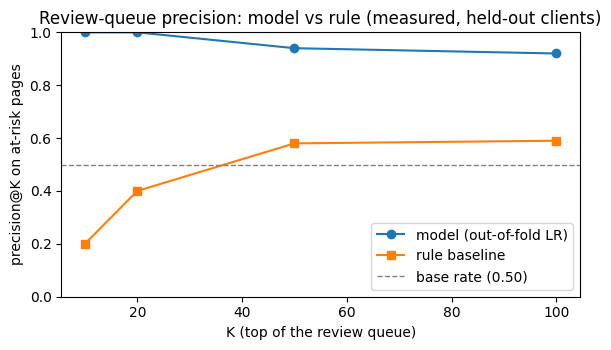

wrote /work/outputs/figures/w07_queue_precision.png


In [8]:
import matplotlib.pyplot as plt

out_dir = repo / "work" / "outputs"
fig_dir = out_dir / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

out_cols = ["action_rank", "content_hash_id", "client_hash_id", "p_at_risk_model",
            "baseline_action_score", "reason_codes", "suggested_action",
            "impressions_prev30d", "search_volume", "main_intent", "content_type",
            "at_risk", "ctr_label"]
queue[out_cols].to_csv(out_dir / "action_playbook_queue.csv", index=False)
print("wrote", out_dir / "action_playbook_queue.csv", "| rows:", len(queue))

# top-K precision, model vs rule vs base rate - one figure the paper can reuse
rule_s = df["baseline_action_score"].to_numpy()
ks = [10, 20, 50, 100]
model_p = [precision_at_k(oof, y_risk, k) for k in ks]
rule_p = [precision_at_k(rule_s, y_risk, k) for k in ks]

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(ks, model_p, marker="o", label="model (out-of-fold LR)")
ax.plot(ks, rule_p, marker="s", label="rule baseline")
ax.axhline(y_risk.mean(), color="gray", linestyle="--", linewidth=1,
           label=f"base rate ({y_risk.mean():.2f})")
ax.set_ylim(0, 1)
ax.set_xlabel("K (top of the review queue)")
ax.set_ylabel("precision@K on at-risk pages")
ax.set_title("Review-queue precision: model vs rule (measured, held-out clients)")
ax.legend()
fig.tight_layout()
plt.show()
fig_path = fig_dir / "w07_queue_precision.png"
fig.savefig(fig_path, dpi=144)
print("wrote", fig_path)

In [9]:
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.